# Clustering en Segmentación de Clientes

## PAQUETERÍAS

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import plotly.graph_objects as go
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("singhnproud77/eastwestairlines-heirarchical-clustering")

print("Path to dataset files:", path)

100%|██████████| 53.9k/53.9k [00:00<00:00, 43.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/singhnproud77/eastwestairlines-heirarchical-clustering/versions/1


In [3]:
def calculate_kn_distance(X, k=2):
    # Definimos la función para calcular la distancia al k-ésimo vecino más cercano
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs = neigh.fit(X)
    distances, _ = nbrs.kneighbors(X)
    return distances[:, k-1]

def plot_kn_distance(X, k):
    # Definimos la función para trazar la curva de la distancia al k-ésimo vecino más cercano
    distances = calculate_kn_distance(X, k=k)
    distances = np.sort(distances, axis=0)

    # Crear el gráfico de codo
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=list(range(1, len(distances)+1)), y=distances,
                                mode='lines+markers',
                                name='Curva de distancia k'))
    fig.update_layout(title='Curva de distancia k',
                        xaxis_title='Puntos Ordenados por Distancia',
                        yaxis_title=f'Distancia al {k}-ésimo vecino más próximo',
                        showlegend=False)
    fig.show()

In [4]:
for filename in os.listdir(path):
    print(filename)

EastWestAirlines.csv


In [5]:
df = pd.read_csv(os.path.join(path, "EastWestAirlines.csv"))

## EDA

In [6]:
df.columns

Index(['ID', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID                 3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award              3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


### Balance

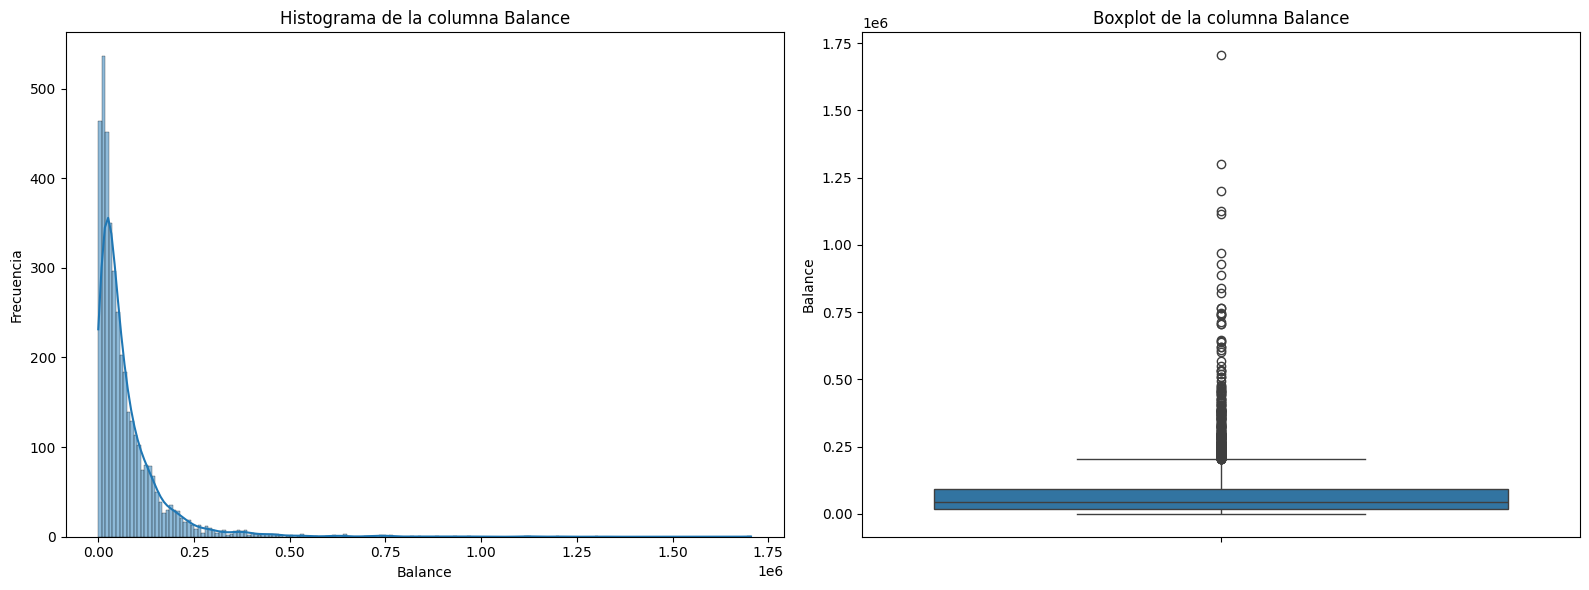

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['Balance'], kde=True, ax=axes[0])
axes[0].set_title('Histograma de la columna Balance')
axes[0].set_xlabel('Balance')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(y=df['Balance'], ax=axes[1])
axes[1].set_title('Boxplot de la columna Balance')
axes[1].set_ylabel('Balance')

plt.tight_layout()
plt.show()

### Número de Vuelos en los últimos 12 meses

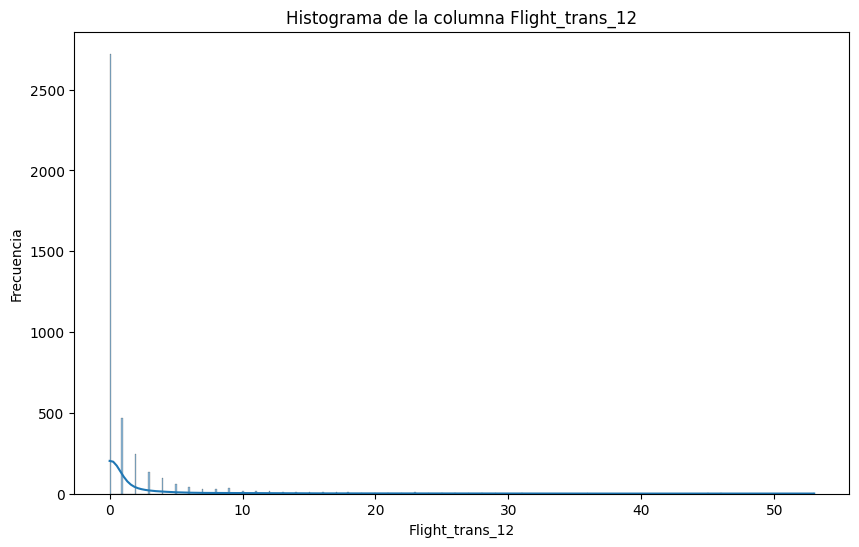

In [9]:

plt.figure(figsize=(10, 6))
sns.histplot(df['Flight_trans_12'], kde=True)
plt.title('Histograma de la columna Flight_trans_12')
plt.xlabel('Flight_trans_12')
plt.ylabel('Frecuencia')
plt.show()

### Bonus miles( Millas ganadas con acciones o actividades que no sean vuelos)

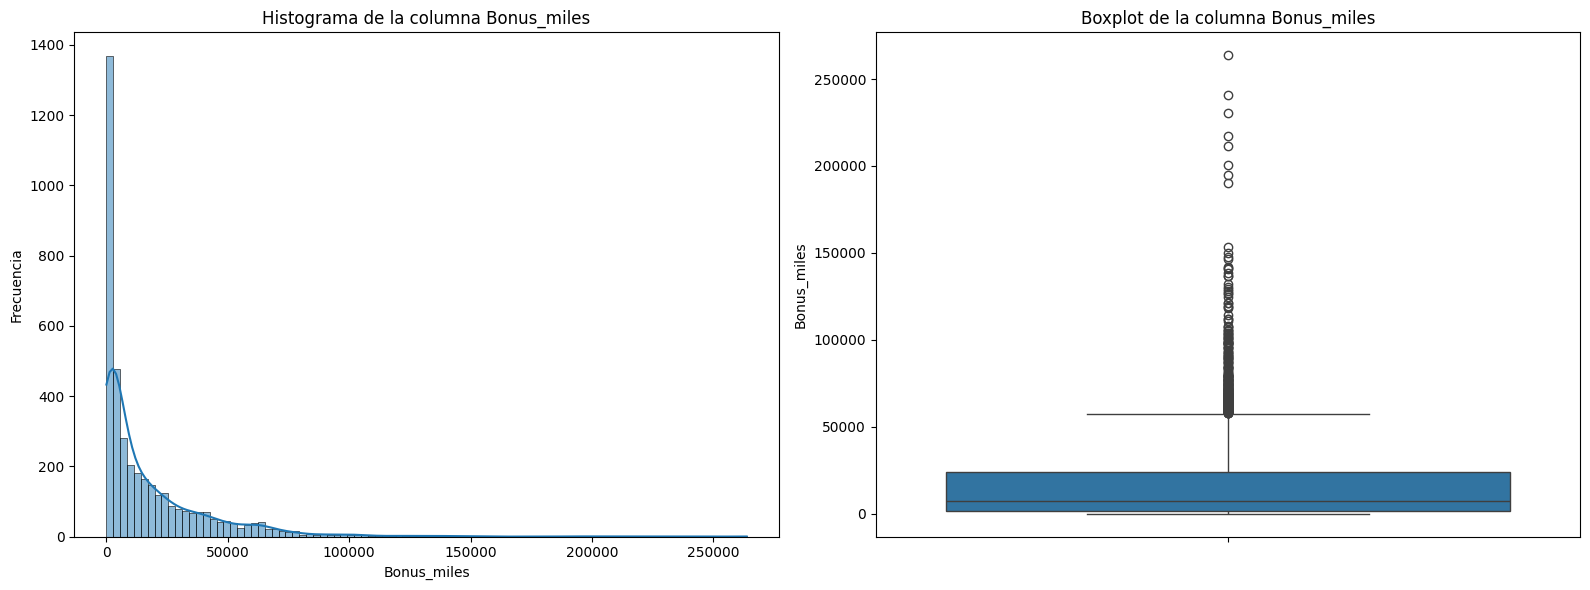

In [10]:


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['Bonus_miles'], kde=True, ax=axes[0])
axes[0].set_title('Histograma de la columna Bonus_miles')
axes[0].set_xlabel('Bonus_miles')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(y=df['Bonus_miles'], ax=axes[1])
axes[1].set_title('Boxplot de la columna Bonus_miles')
axes[1].set_ylabel('Bonus_miles')

plt.tight_layout()
plt.show()

### Tarjetas de Crédito

Estas tres variables corresponden a las diferentes tarjetas de crédito de las cuales se tienen registro, dentro de cada tarjeta de crédito hay distintos niveles en donde se aprecia de cierta manera el valor financiero de cada usuario

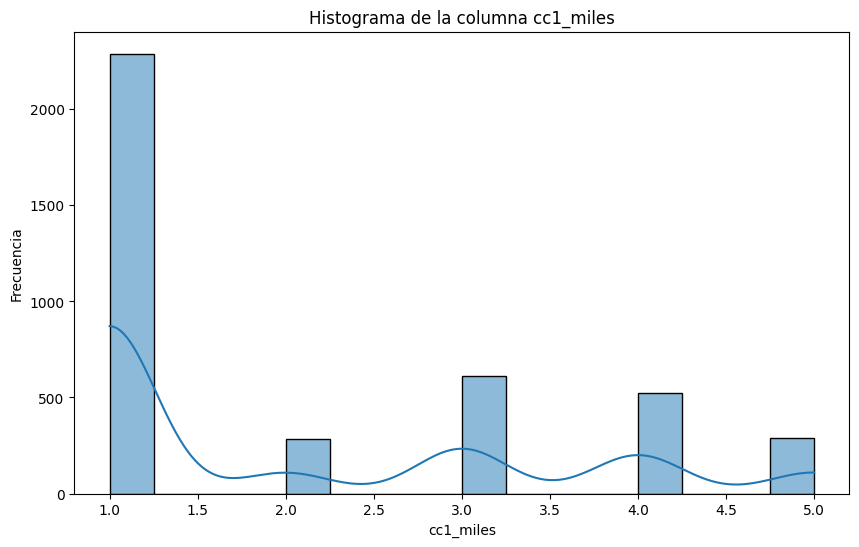

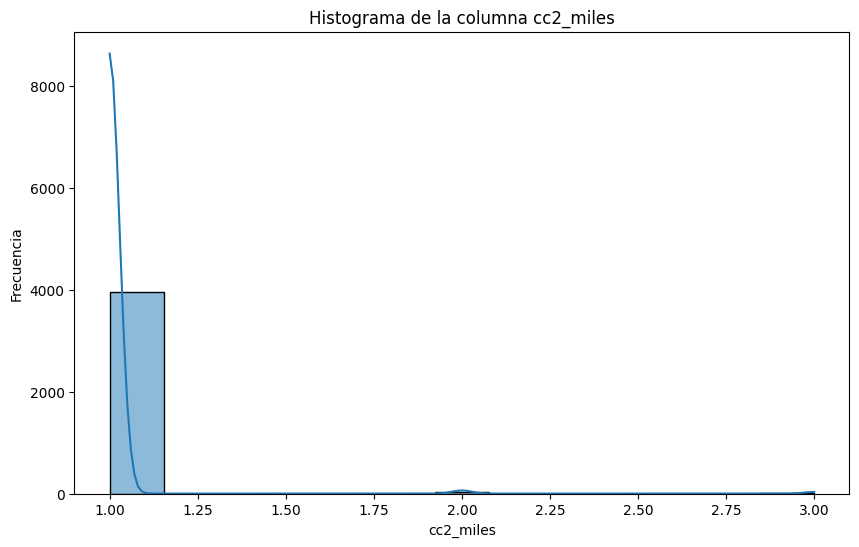

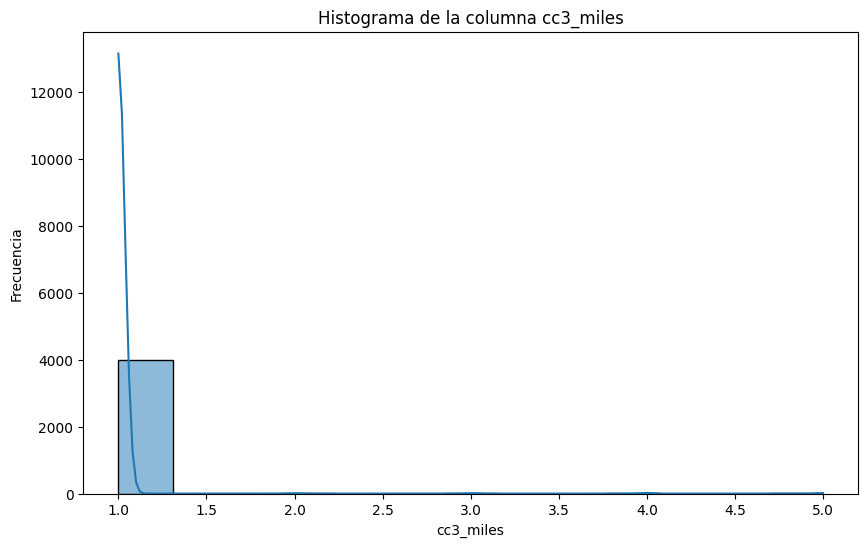

In [11]:


columns_to_plot = ['cc1_miles', 'cc2_miles', 'cc3_miles']

for column in columns_to_plot:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[column], kde=True)
    plt.title(f'Histograma de la columna {column}')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')
    plt.show()

In [12]:
df['Days_since_enroll'].max()

8296

In [13]:
df['Days_since_enroll'].min()

2

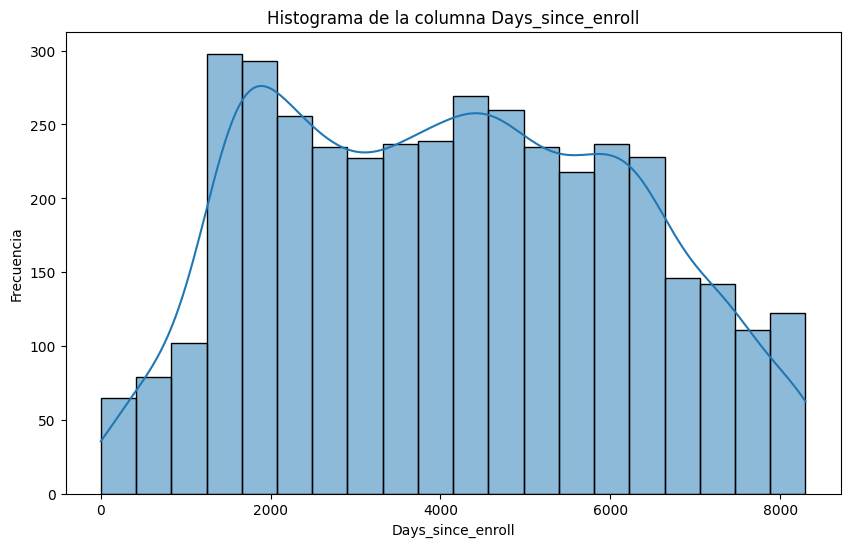

In [14]:


plt.figure(figsize=(10, 6))
sns.histplot(df['Days_since_enroll'], kde=True)
plt.title('Histograma de la columna Days_since_enroll')
plt.xlabel('Days_since_enroll')
plt.ylabel('Frecuencia')
plt.show()

## DATA WRANGLING

Se va a crear una variable para ver las millas totales, sumando las millas acumuladas en cada una de las tarjetas de crédito, para saber las millas totales por cliente o usuario

In [15]:
df['total_miles'] = df['cc1_miles'] + df['cc2_miles'] + df['cc3_miles']

Se va a crear una variable de "performance" para saber su balance en el tiempo

In [16]:
df['flight_performance']= df['Balance'] / df['Days_since_enroll']

Esta última variable es para saber las millas promedio por vuelo

In [17]:
df["millas_promedio"]= df['Flight_miles_12mo'] / df['Flight_trans_12']

In [18]:
df['millas_promedio'] = df['millas_promedio'].fillna(0)

### Transformación y Escalado de los datos

Debido a la disparidad y outliers detectados en el EDA, se aplica un tratamiento diferenciado: transformación logarítmica (log1p) en variables monetarias/de conteo con sesgo alto, una variable flag para Qual_miles (94% ceros, zero-inflated), y sin transformación en cc2_miles/cc3_miles al ser variables ordinales casi constantes (>99% en una sola categoría) con effect size despreciable en el perfilamiento final.

In [19]:
var_continuas = ['Balance', 'Bonus_miles', 'Days_since_enroll', 'Flight_miles_12mo', 'Flight_trans_12', 'Qual_miles', 'total_miles', 'flight_performance', 'millas_promedio', 'Bonus_trans']

In [20]:
print(df[['cc1_miles','cc2_miles','cc3_miles']].nunique())
print((df['cc2_miles']==1).mean(), (df['cc3_miles']==1).mean())  # % en la categoría dominante

# Flag para variable zero-inflated ANTES de transformar
df['has_qual_miles'] = (df['Qual_miles'] > 0).astype(int)

df_transformed = df.copy()
for col in var_continuas:
    df_transformed[col] = np.log1p(df_transformed[col])
df_transformed['millas_promedio'] = df_transformed['millas_promedio'].fillna(0)

cc1_miles    5
cc2_miles    3
cc3_miles    5
dtype: int64
0.989247311827957 0.9954988747186797


In [21]:
df_transformed = df.copy()
for col in var_continuas:
    df_transformed[col] = np.log1p(df_transformed[col])

# Impute NaN values in 'millas_promedio' with 0
df_transformed['millas_promedio'].fillna(0, inplace=True)

display(df_transformed.head())

/tmp/ipykernel_3517/882073766.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_transformed['millas_promedio'].fillna(0, inplace=True)


,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award,total_miles,flight_performance,millas_promedio,has_qual_miles
0,1,10.245089,0.0,1,1,1,5.164786,0.693147,0.000000,0.000000,8.853808,0,1.386294,1.613515,0.000000,0
1,2,9.865007,0.0,1,1,1,5.375278,1.098612,0.000000,0.000000,8.849227,0,1.386294,1.324889,0.000000,0
2,3,10.629949,0.0,1,1,1,8.324579,1.609438,0.000000,0.000000,8.858653,0,1.386294,1.928496,0.000000,0
3,4,9.600827,0.0,1,1,1,6.216606,0.693147,0.000000,0.000000,8.846929,0,1.386294,1.139572,0.000000,0
4,5,11.490199,0.0,4,1,1,10.675931,3.295837,7.639161,1.609438,8.844481,1,1.945910,2.714394,6.254309,0


In [22]:


variables_escaladas = df_transformed.columns.tolist()
variables_escaladas.remove('ID')

scaler = StandardScaler()
df_escalado = scaler.fit_transform(df_transformed[variables_escaladas])

# Convert the scaled data back to a DataFrame for easier handling
df_escalado = pd.DataFrame(df_escalado, columns=variables_escaladas)

display(df_escalado.head())

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award,total_miles,flight_performance,millas_promedio,has_qual_miles
0,-0.240588,-0.243383,-0.769578,-0.098242,-0.062767,-0.829165,-1.350586,-0.669104,-0.576530,0.991086,-0.766919,-0.808425,-0.948906,-0.677077,-0.244743
1,-0.538514,-0.243383,-0.769578,-0.098242,-0.062767,-0.764962,-0.967138,-0.669104,-0.576530,0.984733,-0.766919,-0.808425,-1.232953,-0.677077,-0.244743
2,0.061081,-0.243383,-0.769578,-0.098242,-0.062767,0.134622,-0.484051,-0.669104,-0.576530,0.997804,-0.766919,-0.808425,-0.638922,-0.677077,-0.244743
3,-0.745589,-0.243383,-0.769578,-0.098242,-0.062767,-0.508343,-1.350586,-0.669104,-0.576530,0.981545,-0.766919,-0.808425,-1.415330,-0.677077,-0.244743
4,0.735382,-0.243383,1.409471,-0.098242,-0.062767,0.851822,1.110774,1.760457,1.575216,0.978150,1.303918,1.387109,0.134507,1.671198,-0.244743


In [23]:
df_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  3999 non-null   int64  
 1   Balance             3999 non-null   float64
 2   Qual_miles          3999 non-null   float64
 3   cc1_miles           3999 non-null   int64  
 4   cc2_miles           3999 non-null   int64  
 5   cc3_miles           3999 non-null   int64  
 6   Bonus_miles         3999 non-null   float64
 7   Bonus_trans         3999 non-null   float64
 8   Flight_miles_12mo   3999 non-null   float64
 9   Flight_trans_12     3999 non-null   float64
 10  Days_since_enroll   3999 non-null   float64
 11  Award               3999 non-null   int64  
 12  total_miles         3999 non-null   float64
 13  flight_performance  3999 non-null   float64
 14  millas_promedio     3999 non-null   float64
 15  has_qual_miles      3999 non-null   int64  
dtypes: flo

## Modelos

### Correlación entre variables (justificación de t-SNE sobre PCA)

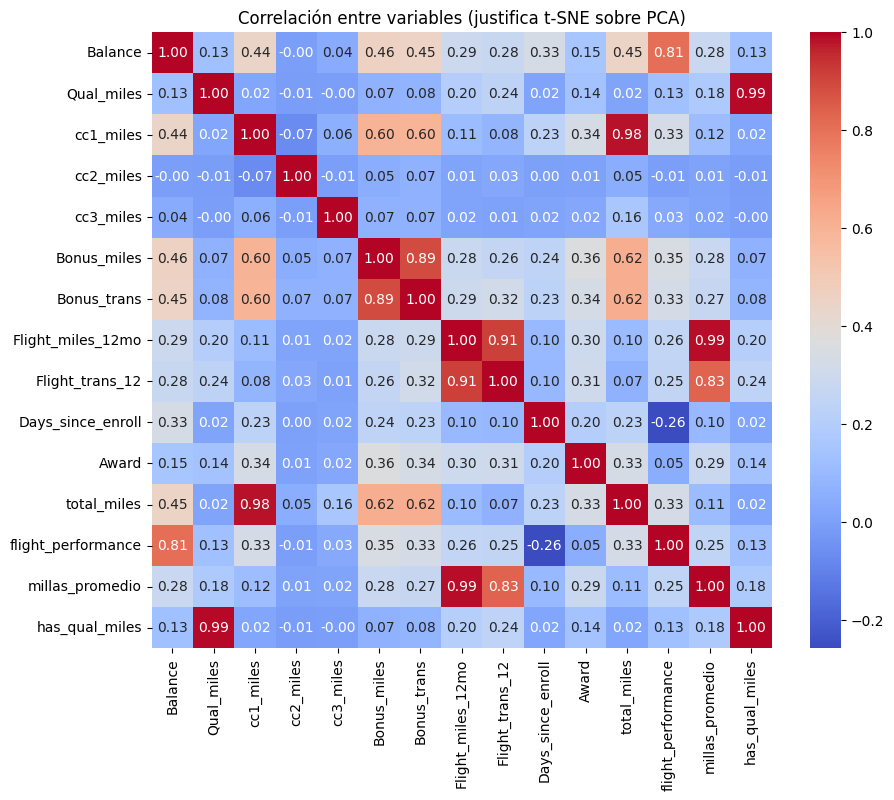

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(df_transformed[variables_escaladas].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlación entre variables (justifica t-SNE sobre PCA)')
plt.show()

### Calibración de t-SNE

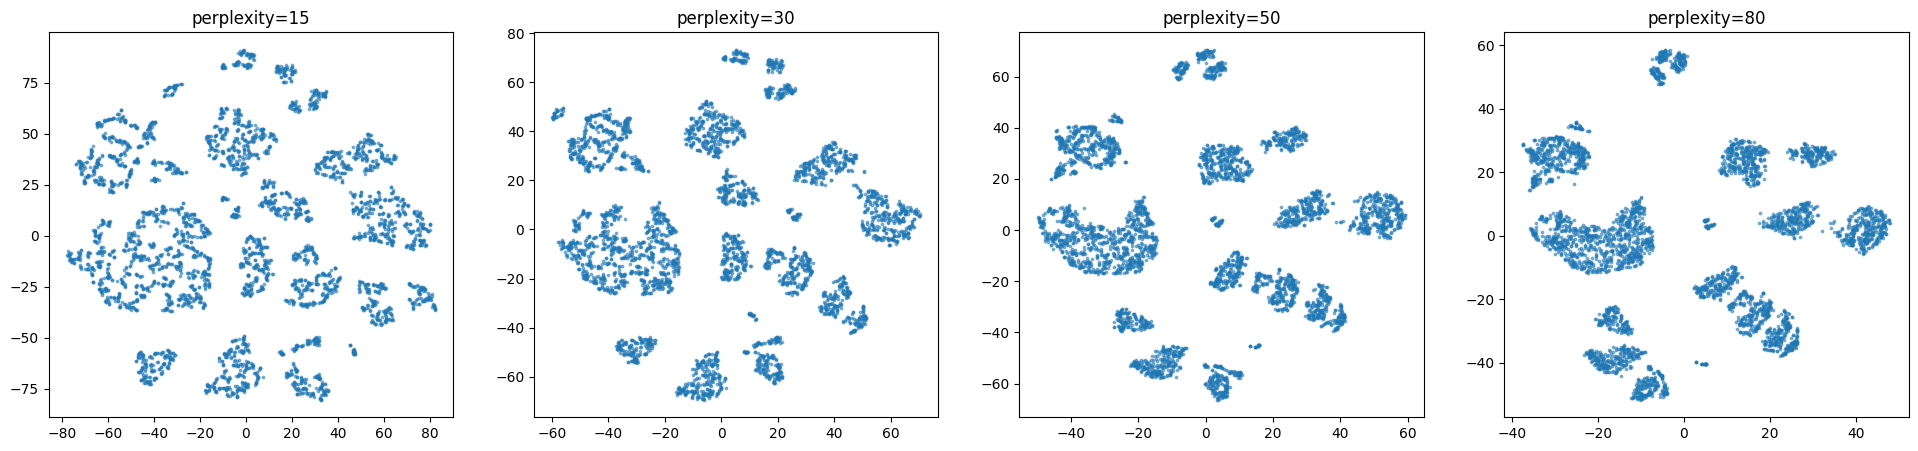

In [25]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 4, figsize=(24,5))
for ax, perp in zip(axes, [15, 30, 50, 80]):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=1000, init='pca')
    emb = tsne.fit_transform(df_escalado)
    ax.scatter(emb[:,0], emb[:,1], s=3, alpha=0.5)
    ax.set_title(f'perplexity={perp}')
plt.show()

In [26]:
# Elegimos perplexity=50 como la más estable, generamos el resultado final para usar después
tsne_final = TSNE(n_components=2, perplexity=50, random_state=42, max_iter=1000, init='pca')
tsne_results = tsne_final.fit_transform(df_escalado)
df_tsne = pd.DataFrame(tsne_results, columns=['tsne_component_1', 'tsne_component_2'])

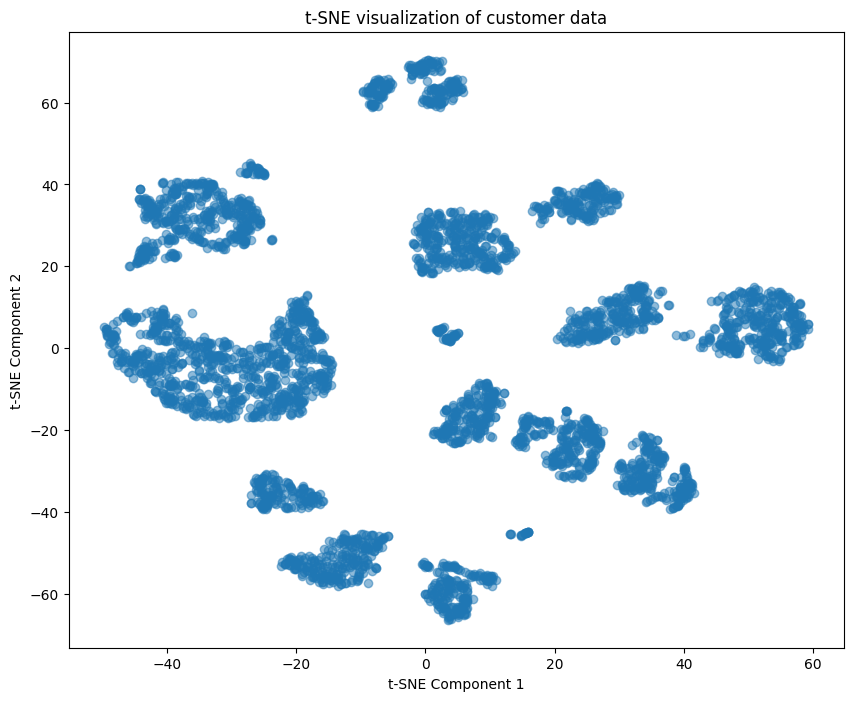

In [27]:
plt.figure(figsize=(10, 8))
plt.scatter(df_tsne['tsne_component_1'], df_tsne['tsne_component_2'], alpha=0.5)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE visualization of customer data')
plt.show()

### DBSCAN


In [28]:
df_escalado.columns

Index(['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award', 'total_miles', 'flight_performance',
       'millas_promedio', 'has_qual_miles'],
      dtype='object')

In [29]:
# Preparamos las características relevantes
X = df_escalado[['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award', 'total_miles', 'flight_performance',
       'millas_promedio']]
#X_scaled = StandardScaler().fit_transform(X)

plot_kn_distance(X, 24)

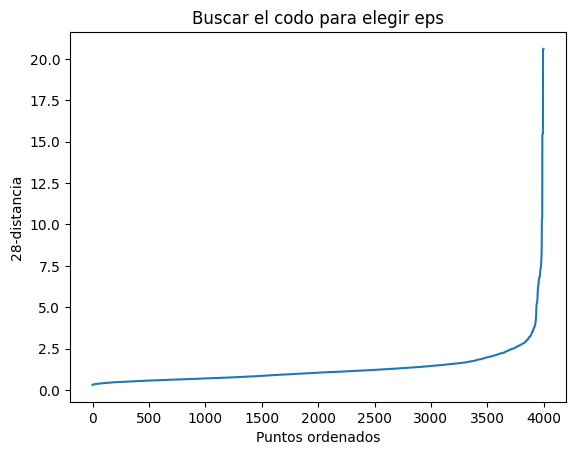

In [30]:
from sklearn.neighbors import NearestNeighbors

k = 2 * X.shape[1]  # regla práctica: 2 x número de dimensiones
nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, _ = nbrs.kneighbors(X)
k_dist = np.sort(distances[:,-1])
plt.plot(k_dist); plt.ylabel(f'{k}-distancia'); plt.xlabel('Puntos ordenados')
plt.title('Buscar el codo para elegir eps')
plt.show()

In [31]:
# Aplicamos DBSCAN
dbs = DBSCAN(eps=3.5, min_samples=35).fit(X)
labels = dbs.labels_

df['Cluster'] = labels



#### Por qué se descarta DBSCAN para segmentación de negocio

In [32]:
from collections import Counter
print("Distribución de DBSCAN con eps=3.5:")
print(Counter(dbs.labels_))
print(f"Clusters reales (sin contar ruido): {len(set(dbs.labels_)) - (1 if -1 in dbs.labels_ else 0)}")
print(f"% de ruido: {(dbs.labels_==-1).mean()*100:.1f}%")

Distribución de DBSCAN con eps=3.5:
Counter({np.int64(0): 3935, np.int64(-1): 64})
Clusters reales (sin contar ruido): 1
% de ruido: 1.6%


### Comparación de modelos: KMeans vs. GMM

In [33]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

for k in [2,3,4,5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    print(f'KMeans k={k}: silhouette={silhouette_score(X, km.labels_):.3f}')

for k in [2,3,4,5]:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5).fit(X)
    print(f'GMM k={k}: BIC={gmm.bic(X):.0f}, silhouette={silhouette_score(X, gmm.predict(X)):.3f}')

KMeans k=2: silhouette=0.238
KMeans k=3: silhouette=0.257
KMeans k=4: silhouette=0.260
KMeans k=5: silhouette=0.232
GMM k=2: BIC=-54705, silhouette=0.283
GMM k=3: BIC=-104443, silhouette=0.254
GMM k=4: BIC=-135000, silhouette=0.271
GMM k=5: BIC=-169796, silhouette=0.207


### Modelo final: KMeans (k=3)

In [34]:
# Elegimos el k final con base en el silhouette de arriba
k_final = 3
modelo_final = KMeans(n_clusters=k_final, random_state=42, n_init=10).fit(X)
df['Cluster'] = modelo_final.labels_
print(f"\nModelo final: KMeans k={k_final}")
print(df['Cluster'].value_counts())


Modelo final: KMeans k=3
Cluster
2    1573
0    1215
1    1211
Name: count, dtype: int64


In [35]:
X_array = X.values if hasattr(X, 'values') else X

# --- PASO 2: REDUCCIÓN DE DIMENSIONES PARA VISUALIZACIÓN ---
# Aplicamos PCA a los datos escalados (X) para obtener 2 componentes
pca = PCA(n_components=2)
components = pca.fit_transform(X_array)

# Creamos un DataFrame para la visualización
pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster'].astype(str) #

# --- PASO 3: GRÁFICO DE DISPERSIÓN 2D ---
fig = px.scatter(pca_df,
                 x='PC1',
                 y='PC2',
                 color='Cluster',
                 title='Segmentación final (KMeans) — Proyección PCA',
                 labels={'color': 'Cluster'},
                 color_discrete_sequence=px.colors.qualitative.Plotly,
                 opacity=0.8)

fig.show()

# Opcional: Ejecutar para ver la distribución del clúster
print("\nDistribución del tamaño de los clústeres:")
print(df['Cluster'].value_counts())


Distribución del tamaño de los clústeres:
Cluster
2    1573
0    1215
1    1211
Name: count, dtype: int64


In [36]:
# Reutilizamos el t-SNE ya calibrado (perplexity=50) de la celda anterior, no recalculamos
df_tsne['Cluster'] = df['Cluster'].astype(str)  # Etiquetas de KMeans

In [37]:
fig = px.scatter(df_tsne,
                 x='tsne_component_1',
                 y='tsne_component_2',
                 color='Cluster',
                 title='Segmentación final (KMeans) — Visualización con t-SNE calibrado',
                 labels={'color': 'Cluster'},
                 color_discrete_sequence=px.colors.qualitative.Plotly,
                 opacity=0.8)
fig.show()

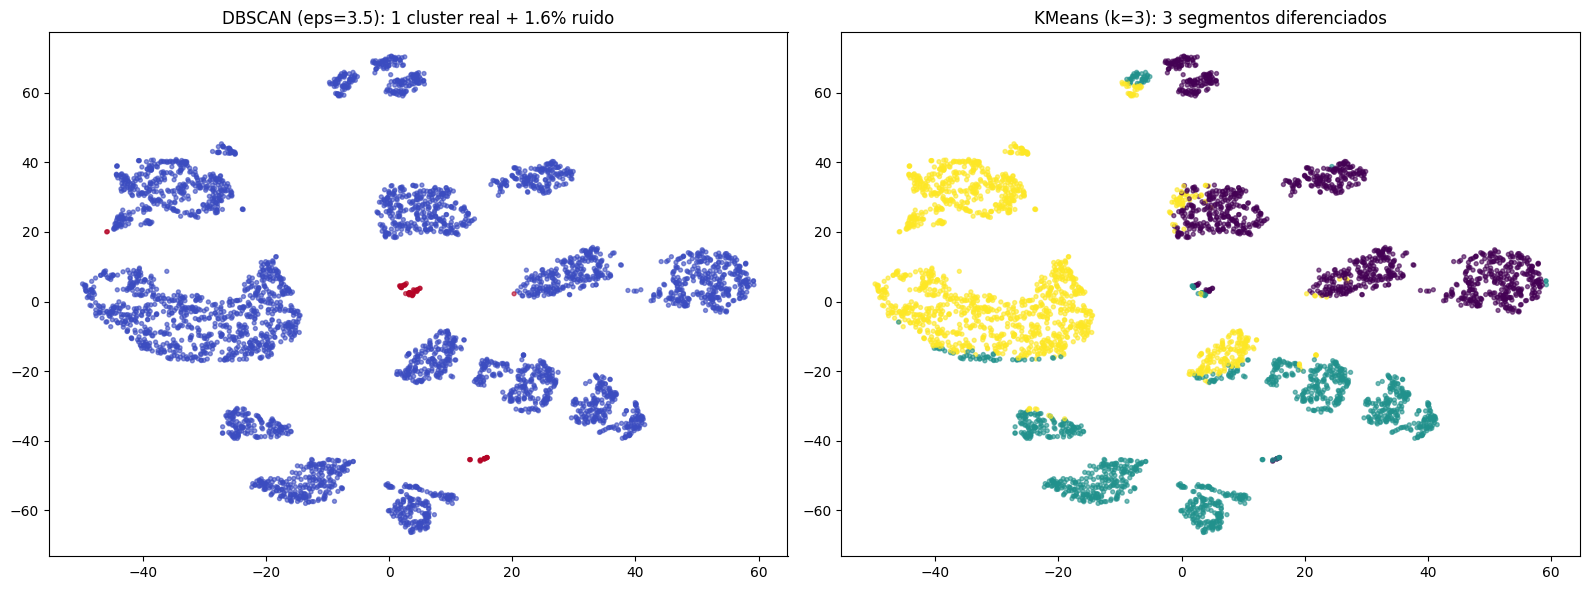

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

axes[0].scatter(df_tsne['tsne_component_1'], df_tsne['tsne_component_2'],
                c=(dbs.labels_==-1).astype(int), cmap='coolwarm', s=8, alpha=0.6)
axes[0].set_title(f'DBSCAN (eps=3.5): 1 cluster real + {(dbs.labels_==-1).mean()*100:.1f}% ruido')

axes[1].scatter(df_tsne['tsne_component_1'], df_tsne['tsne_component_2'],
                c=df['Cluster'], cmap='viridis', s=8, alpha=0.6)
axes[1].set_title('KMeans (k=3): 3 segmentos diferenciados')

plt.tight_layout()
plt.show()

## Perfilamiento


In [39]:

# PASO 2: PERFILAMIENTO Y CÁLCULO DE ESTADÍSTICAS

VARIABLES_CLAVE = [
    'Balance',
    'cc1_miles', # Nivel de tarjeta (1-5)
    'Bonus_miles',
    'Flight_trans_12', # Frecuencia de vuelo
    'Days_since_enroll', # Antigüedad
    'millas_promedio' # Tu variable calculada
]


In [40]:
# 1. Calculamos la media para cada cluster (usamos la media para una visión rápida)
perfil_cluster = df.groupby('Cluster')[VARIABLES_CLAVE].mean().round(2)

# 2. Obtenemos el tamaño del cluster para el contexto
tamaño_cluster = df['Cluster'].value_counts().rename('Tamaño')

# Concatenamos el tamaño al perfil para una visión completa
perfil_final = pd.concat([tamaño_cluster, perfil_cluster], axis=1)

print("\n--- Perfil Final de los Clústeres (Medias de Variables Originales) ---")
print(perfil_final)


--- Perfil Final de los Clústeres (Medias de Variables Originales) ---
         Tamaño    Balance  cc1_miles  Bonus_miles  Flight_trans_12  \
Cluster                                                               
2          1573   26728.24       1.01      2324.62             0.05   
0          1215  116209.57       2.34     25392.23             4.46   
1          1211   91737.04       3.14     28120.60             0.00   

         Days_since_enroll  millas_promedio  
Cluster                                      
2                  3561.63             6.95  
0                  4418.36           368.10  
1                  4541.18             0.17  


In [41]:
perfil_final

,Tamaño,Balance,cc1_miles,Bonus_miles,Flight_trans_12,Days_since_enroll,millas_promedio
Cluster,,,,,,,
2,1573,26728.24,1.01,2324.62,0.05,3561.63,6.95
0,1215,116209.57,2.34,25392.23,4.46,4418.36,368.10
1,1211,91737.04,3.14,28120.60,0.00,4541.18,0.17


### Validación estadística del modelo final

In [42]:
from scipy.stats import kruskal

labels_reales = sorted(df['Cluster'].unique())
k_clusters = len(labels_reales)
n = len(df)

for col in VARIABLES_CLAVE:
    groups = [df[col][df['Cluster']==c] for c in labels_reales]
    stat, p = kruskal(*groups)
    eps_sq = (stat - k_clusters + 1) / (n - k_clusters)
    print(f'{col}: p={p:.4f}, epsilon²={eps_sq:.3f}')

Balance: p=0.0000, epsilon²=0.354
cc1_miles: p=0.0000, epsilon²=0.497
Bonus_miles: p=0.0000, epsilon²=0.552
Flight_trans_12: p=0.0000, epsilon²=0.912
Days_since_enroll: p=0.0000, epsilon²=0.048
millas_promedio: p=0.0000, epsilon²=0.910


### GMM como contraste (Cross Validation)

In [43]:
# --- Entrenamos GMM final con el mismo k
gmm_final = GaussianMixture(n_components=3, random_state=42, n_init=5).fit(X)
df['Cluster_GMM'] = gmm_final.predict(X)

print("Silhouette KMeans:", round(silhouette_score(X, df['Cluster'].values), 3))
print("Silhouette GMM:", round(silhouette_score(X, df['Cluster_GMM'].values), 3))

print("\n=== Perfil GMM ===")
print(df.groupby('Cluster_GMM')[VARIABLES_CLAVE].mean().round(2))

print("\n=== Kruskal-Wallis + epsilon² (GMM) ===")
k_gmm = df['Cluster_GMM'].nunique()
for col in VARIABLES_CLAVE:
    groups = [df[col][df['Cluster_GMM']==c] for c in sorted(df['Cluster_GMM'].unique())]
    stat, p = kruskal(*groups)
    eps_sq = (stat - k_gmm + 1) / (n - k_gmm)
    print(f'{col}: p={p:.4f}, epsilon²={eps_sq:.3f}')

Silhouette KMeans: 0.257
Silhouette GMM: 0.254

=== Perfil GMM ===
               Balance  cc1_miles  Bonus_miles  Flight_trans_12  \
Cluster_GMM                                                       
0             87011.97       3.28     29169.09             0.00   
1             33534.79       1.00      2644.13             0.00   
2            111152.06       2.29     24397.10             4.28   

             Days_since_enroll  millas_promedio  
Cluster_GMM                                      
0                      4487.19             0.00  
1                      3635.65             0.00  
2                      4388.19           357.27  

=== Kruskal-Wallis + epsilon² (GMM) ===
Balance: p=0.0000, epsilon²=0.255
cc1_miles: p=0.0000, epsilon²=0.553
Bonus_miles: p=0.0000, epsilon²=0.522
Flight_trans_12: p=0.0000, epsilon²=0.947
Days_since_enroll: p=0.0000, epsilon²=0.036
millas_promedio: p=0.0000, epsilon²=0.945


In [44]:
import pickle

with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(modelo_final, f)
print("Modelo KMeans final guardado en kmeans_model.pkl")

Modelo KMeans final guardado en kmeans_model.pkl


In [45]:
df[df['Cluster']==1]['Flight_trans_12'].describe()

,Flight_trans_12
count,1211.000000
mean,0.003303
std,0.057401
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000
